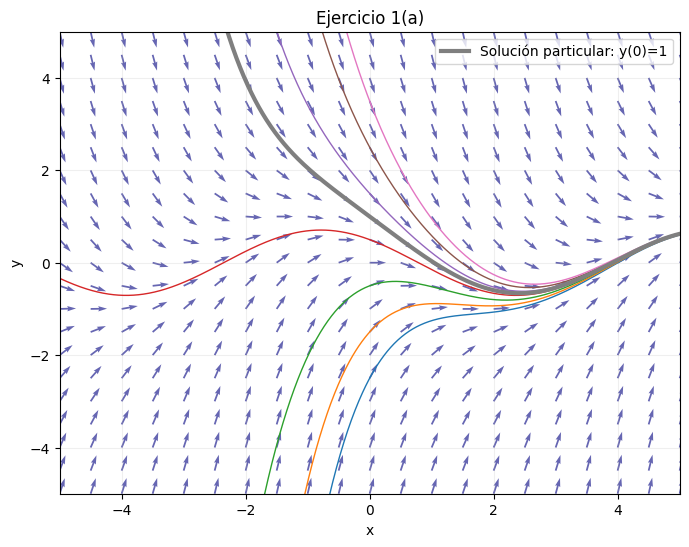

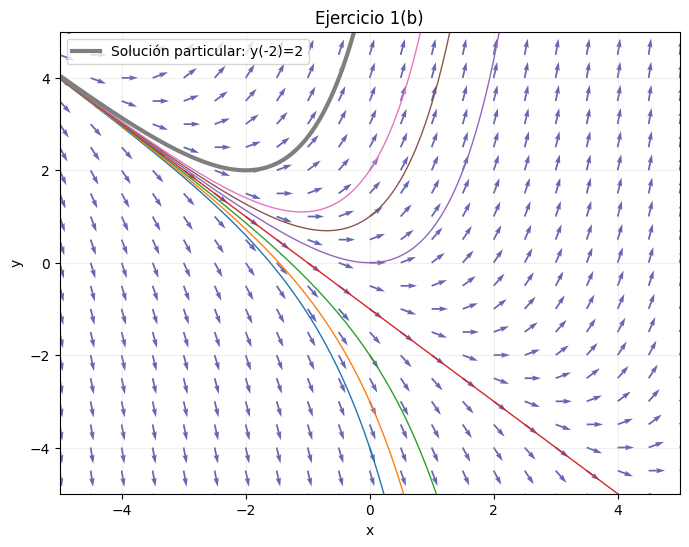

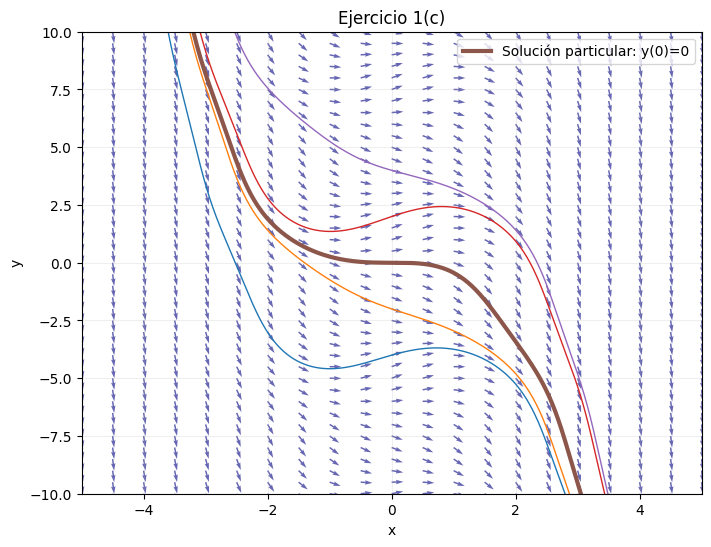

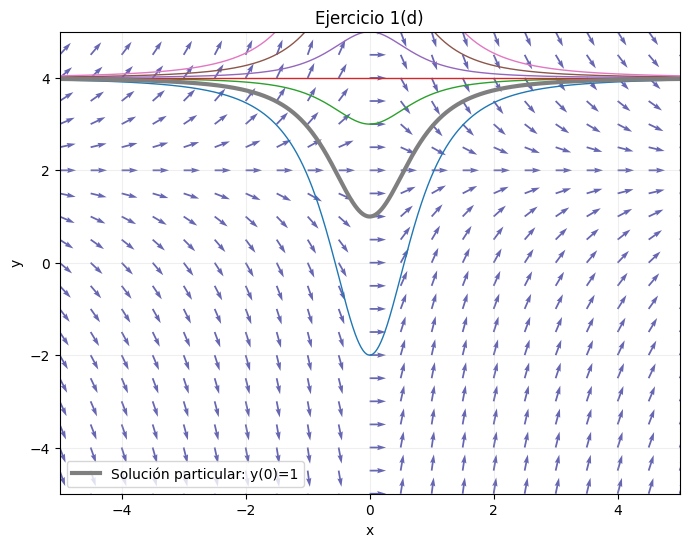

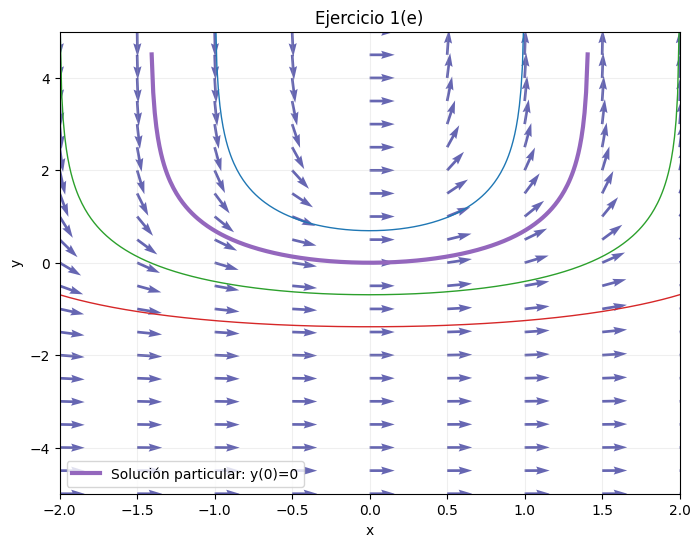

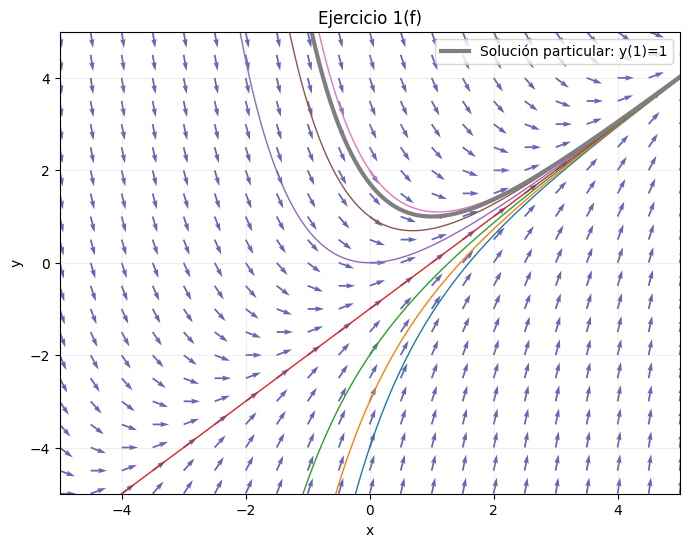

In [2]:
# ============================================================
# GUÍA DE TRABAJO #1
# PUNTO 1 - CAMPOS DE PENDIENTES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# ============================================================
# FUNCIÓN PARA CONSTRUIR EL CAMPO DE PENDIENTES
# ============================================================

def campo_pendientes(ax, f, xlim=(-5, 5), ylim=(-5, 5), h=0.5):

    m = np.arange(xlim[0], xlim[1] + h, h)
    n = np.arange(ylim[0], ylim[1] + h, h)

    X, Y = np.meshgrid(m, n)

    pendiente = f(X, Y)


    norm = np.sqrt(1 + pendiente**2)

    U = 1 / norm
    V = pendiente / norm

    ax.quiver(
        X, Y, U, V,
        angles='xy',
        color='navy',
        alpha=0.6
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_xlabel('x')
    ax.set_ylabel('y')

    ax.grid(alpha=0.2)


# ============================================================
# EJERCICIO 1(a)
# y' = -y - sin(x)
# y(0) = 1
# ============================================================

def f_a(x, y):
    return -y - np.sin(x)


x = np.linspace(-5, 5, 1000)

fig, ax = plt.subplots(figsize=(8, 6))

campo_pendientes(ax, f_a)

# Familia de soluciones
for C in [-3, -2, -1, 0, 1, 2, 3]:

    y = C * np.exp(-x) + (
        np.cos(x) - np.sin(x)
    ) / 2

    ax.plot(x, y, linewidth=1)


# Solución particular y(0)=1
y_particular = (
    0.5 * np.exp(-x)
    + (np.cos(x) - np.sin(x)) / 2
)

ax.plot(
    x,
    y_particular,
    linewidth=3,
    label='Solución particular: y(0)=1'
)

ax.set_title("Ejercicio 1(a)")
ax.legend()

plt.show()


# ============================================================
# EJERCICIO 1(b)
# y' = x + y
# y(-2) = 2
# ============================================================

def f_b(x, y):
    return x + y


fig, ax = plt.subplots(figsize=(8, 6))

campo_pendientes(ax, f_b)

# Familia de soluciones
for C in [-3, -2, -1, 0, 1, 2, 3]:

    y = C * np.exp(x) - x - 1

    ax.plot(x, y, linewidth=1)


# Solución particular y(-2)=2
y_particular = np.exp(x + 2) - x - 1

ax.plot(
    x,
    y_particular,
    linewidth=3,
    label='Solución particular: y(-2)=2'
)

ax.set_title("Ejercicio 1(b)")
ax.legend()

plt.show()


# ============================================================
# EJERCICIO 1(c)
# y' = -x² + sin(y)
#
# No tiene condición inicial.
# Elegimos y(0)=0.
#
# Se utilizan soluciones numéricas.
# ============================================================

def f_c(x, y):
    return -x**2 + np.sin(y)


fig, ax = plt.subplots(figsize=(8, 6))

campo_pendientes(
    ax,
    f_c,
    xlim=(-5, 5),
    ylim=(-10, 10)
)


# ------------------------------------------------------------
# Función para obtener una solución numérica
# hacia la derecha y hacia la izquierda desde x=0
# ------------------------------------------------------------

def solucion_numerica_c(y0):

    x_derecha = np.linspace(0, 5, 500)
    x_izquierda = np.linspace(0, -5, 500)

    sol_derecha = solve_ivp(
        f_c,
        (0, 5),
        [y0],
        t_eval=x_derecha,
        max_step=0.05
    )

    sol_izquierda = solve_ivp(
        f_c,
        (0, -5),
        [y0],
        t_eval=x_izquierda,
        max_step=0.05
    )


    x_izquierda = sol_izquierda.t[::-1]
    y_izquierda = sol_izquierda.y[0][::-1]


    x_total = np.concatenate([
        x_izquierda[:-1],
        sol_derecha.t
    ])

    y_total = np.concatenate([
        y_izquierda[:-1],
        sol_derecha.y[0]
    ])

    return x_total, y_total


# Familia de soluciones
for y0 in [-4, -2, 0, 2, 4]:

    x_sol, y_sol = solucion_numerica_c(y0)

    ax.plot(
        x_sol,
        y_sol,
        linewidth=1
    )


# Solución particular y(0)=0
x_sol, y_sol = solucion_numerica_c(0)

ax.plot(
    x_sol,
    y_sol,
    linewidth=3,
    label='Solución particular: y(0)=0'
)

ax.set_title("Ejercicio 1(c)")
ax.legend()

plt.show()


# ============================================================
# EJERCICIO 1(d)
# (x² + 1)y' + 3xy = 6x
#
# No tiene condición inicial.
# Elegimos y(0)=1.
# ============================================================

def f_d(x, y):
    return (6*x - 3*x*y) / (x**2 + 1)


fig, ax = plt.subplots(figsize=(8, 6))

campo_pendientes(ax, f_d)

# Familia de soluciones
for C in [-6, -3, -1, 0, 1, 3, 6]:

    y = 4 + C / (x**2 + 1)**(3/2)

    ax.plot(
        x,
        y,
        linewidth=1
    )


# Solución particular y(0)=1
y_particular = 4 - 3 / (x**2 + 1)**(3/2)

ax.plot(
    x,
    y_particular,
    linewidth=3,
    label='Solución particular: y(0)=1'
)

ax.set_title("Ejercicio 1(d)")
ax.legend()

plt.show()


# ============================================================
# EJERCICIO 1(e)
# y' = x e^y
#
# No tiene condición inicial.
# Elegimos y(0)=0.
# ============================================================

def f_e(x, y):
    return x * np.exp(y)


fig, ax = plt.subplots(figsize=(8, 6))

campo_pendientes(
    ax,
    f_e,
    xlim=(-2, 2),
    ylim=(-5, 5)
)


# Familia de soluciones
for C in [0.5, 1, 2, 4]:

    argumento = C - x**2 / 2

    y = np.full_like(x, np.nan)

    mascara = argumento > 0

    y[mascara] = -np.log(argumento[mascara])

    ax.plot(
        x,
        y,
        linewidth=1
    )


# Solución particular y(0)=0
argumento = 1 - x**2 / 2

y_particular = np.full_like(x, np.nan)

mascara = argumento > 0

y_particular[mascara] = -np.log(argumento[mascara])

ax.plot(
    x,
    y_particular,
    linewidth=3,
    label='Solución particular: y(0)=0'
)

ax.set_title("Ejercicio 1(e)")
ax.legend()

plt.show()


# ============================================================
# EJERCICIO 1(f)
# y' = x - y
# y(1) = 1
# ============================================================

def f_f(x, y):
    return x - y


fig, ax = plt.subplots(figsize=(8, 6))

campo_pendientes(ax, f_f)

# Familia de soluciones
for C in [-3, -2, -1, 0, 1, 2, 3]:

    y = x - 1 + C * np.exp(-x)

    ax.plot(
        x,
        y,
        linewidth=1
    )


# Solución particular y(1)=1
y_particular = x - 1 + np.exp(1 - x)

ax.plot(
    x,
    y_particular,
    linewidth=3,
    label='Solución particular: y(1)=1'
)

ax.set_title("Ejercicio 1(f)")
ax.legend()

plt.show()